In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [18]:
df = pd.read_csv("data.csv")

In [3]:
print(data.head())

  Fund Number Market Cap    Type     Risk    Assets  Turnover Ratio(%)     SD  \
0       RF040      Large  Growth  Average   8524.94              112.0   9.51   
1       RF147      Large   Value  Average    942.15               26.0  10.41   
2       RF221    Mid-Cap  Growth     High    374.63               63.4  15.24   
3       RF309    Mid-Cap   Value  Average   1478.08                6.0   9.51   
4       RF028      Large  Growth  Average  13634.38                5.0  10.93   

   Sharpe Ratio  1YrReturn%  3YrReturn%  5YrReturn%  10YrReturn%  \
0          1.91       11.08       19.29       17.00         8.82   
1          1.88       11.89       18.20       14.60         9.26   
2          1.88       -4.34       12.63       13.02        12.98   
3          1.86        7.95       16.48       15.15         7.40   
4          1.85       11.52       21.55       19.59         8.83   

   Expense Ratio Star Rating  
0           0.82        Four  
1           0.95        Four  
2          

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fund Number        407 non-null    object 
 1   Market Cap         407 non-null    object 
 2   Type               407 non-null    object 
 3   Risk               407 non-null    object 
 4   Assets             407 non-null    float64
 5   Turnover Ratio(%)  407 non-null    float64
 6   SD                 407 non-null    float64
 7   Sharpe Ratio       407 non-null    float64
 8   1YrReturn%         407 non-null    float64
 9   3YrReturn%         407 non-null    float64
 10  5YrReturn%         407 non-null    float64
 11  10YrReturn%        407 non-null    float64
 12  Expense Ratio      407 non-null    float64
 13  Star Rating        407 non-null    object 
dtypes: float64(9), object(5)
memory usage: 44.6+ KB
None


In [5]:
print(data.isnull().sum())

Fund Number          0
Market Cap           0
Type                 0
Risk                 0
Assets               0
Turnover Ratio(%)    0
SD                   0
Sharpe Ratio         0
1YrReturn%           0
3YrReturn%           0
5YrReturn%           0
10YrReturn%          0
Expense Ratio        0
Star Rating          0
dtype: int64


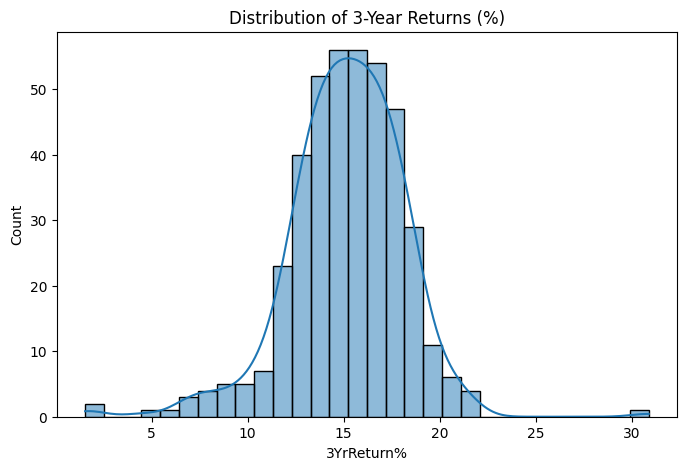

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(data['3YrReturn%'], kde=True, bins=30)
plt.title("Distribution of 3-Year Returns (%)")
plt.xlabel("3YrReturn%")
plt.ylabel("Count")
plt.show()

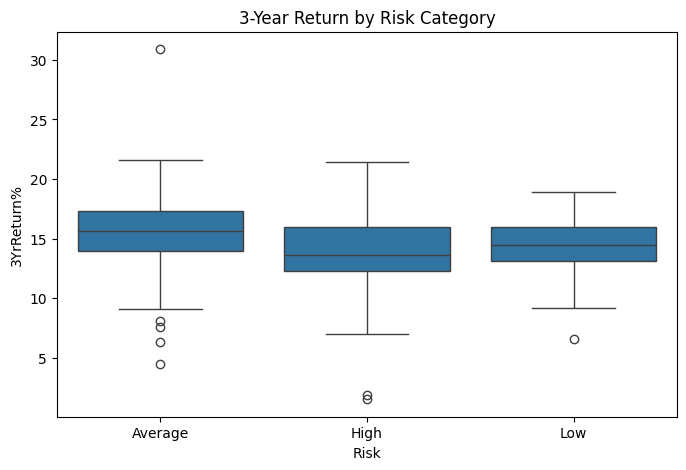

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['Risk'], y=data['3YrReturn%'])
plt.title("3-Year Return by Risk Category")
plt.xlabel("Risk")
plt.ylabel("3YrReturn%")
plt.show()

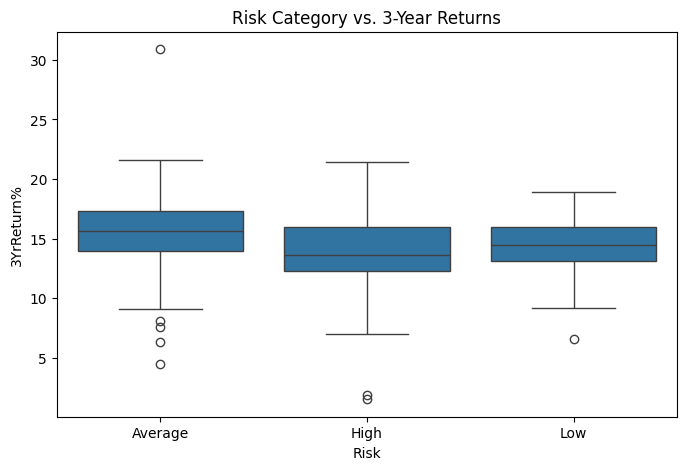

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Risk', y='3YrReturn%', data=df)
plt.title('Risk Category vs. 3-Year Returns')
plt.show()

In [26]:
numeric_cols = ['Assets', 'Turnover Ratio(%)', 'SD', 'Sharpe Ratio', '1YrReturn%', '3YrReturn%', '5YrReturn%', '10YrReturn%', 'Expense Ratio']
corr = data[numeric_cols].corr()

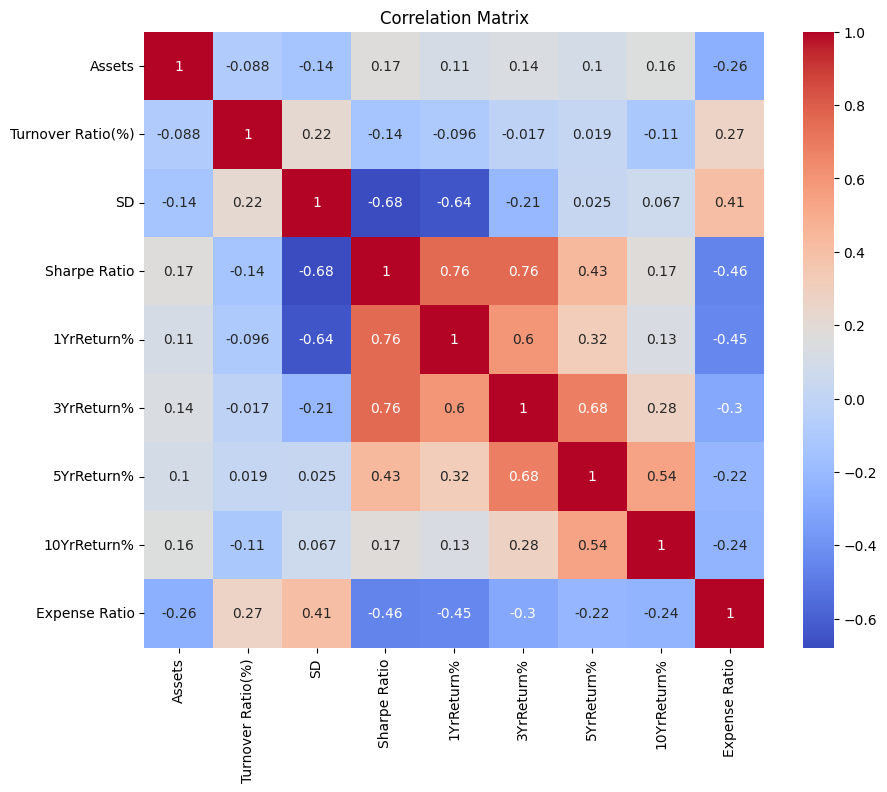

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [28]:
data_encoded = pd.get_dummies(data, columns=['Market Cap', 'Type', 'Risk'], drop_first=True)


In [29]:
data_encoded = pd.get_dummies(data, columns=['Market Cap', 'Type', 'Risk'], drop_first=True)


In [38]:
X = data_encoded.drop(['Fund Number', 'Star Rating', '3YrReturn%'], axis=1)

y = data_encoded['3YrReturn%']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


In [41]:
model = RandomForestRegressor(n_estimators=150, max_depth=9, random_state=4)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=9, n_estimators=150, random_state=4)

In [42]:
predictions = model.predict(X_test)

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [44]:
print("\nModel Performance:")
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))


Model Performance:
RMSE: 1.36
R² Score: 0.84


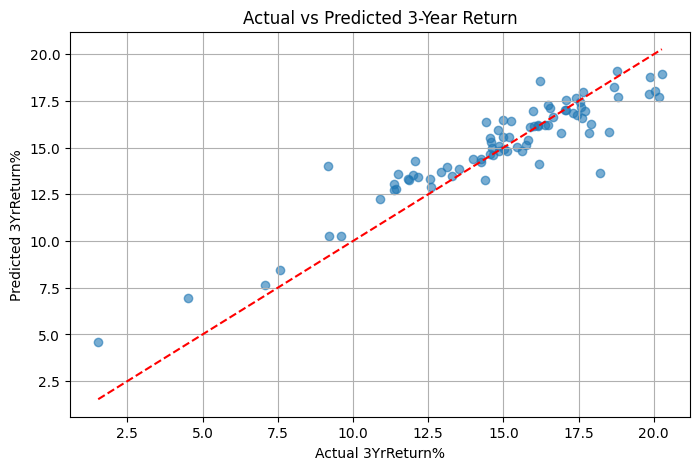

In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual 3YrReturn%")
plt.ylabel("Predicted 3YrReturn%")
plt.title("Actual vs Predicted 3-Year Return")
plt.grid(True)
plt.show()

In [46]:
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)


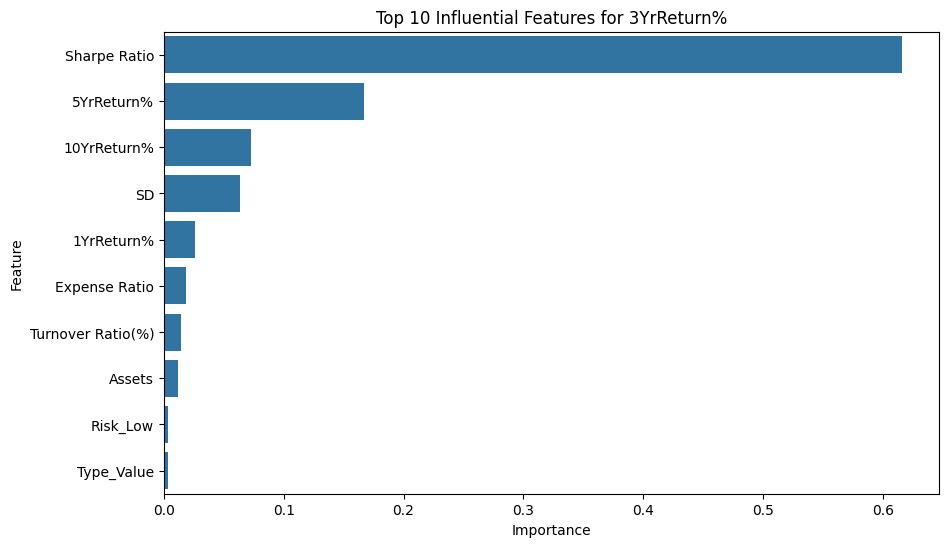

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Influential Features for 3YrReturn%")
plt.show()

In [48]:
top_five = importance_df.head(5)['Feature'].tolist()
print("Top 5 important features influencing 3YrReturn%:")
for i, feature in enumerate(top_five):
    print(f"{i+1}. {feature}")

Top 5 important features influencing 3YrReturn%:
1. Sharpe Ratio
2. 5YrReturn%
3. 10YrReturn%
4. SD
5. 1YrReturn%
